# Notebook 3 - Estacionariedad del O₃ horario en UIZ (UAM Iztapalapa)
**Datos:** SIMAT, contaminantes horarios 2026 (`contaminantes_2026.csv`, ene–feb 2026).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")

RUTA = "/content/contaminantes_2026.csv"
ESTACION = "UIZ"
NLAGS = 72

## Carga de datos

In [4]:
with open(RUTA, encoding="utf-8") as f:
    lineas = [next(f, "") for _ in range(30)]
fila_header = next(i for i, l in enumerate(lineas) if l.lower().startswith('"date"'))

raw = pd.read_csv(RUTA, skiprows=fila_header, encoding="utf-8")
raw["date"] = pd.to_datetime(raw["date"])
raw["valor"] = pd.to_numeric(raw["valor"], errors="coerce")
raw.loc[raw["valor"] < 0, "valor"] = np.nan          # negativos = lecturas inválidas

o3 = (raw[(raw["id_station"] == ESTACION) & (raw["id_parameter"] == "O3")]
        .set_index("date")["valor"].sort_index())

# Rejilla horaria completa para que los huecos aparezcan como NaN explícitos
rejilla = pd.date_range(o3.index.min(), o3.index.max(), freq="h")
o3 = o3.reindex(rejilla)
o3.index.name = "date"
print(f"{ESTACION} – O3: {len(o3)} horas, de {o3.index.min()} a {o3.index.max()}")
o3.head()

UIZ – O3: 1416 horas, de 2026-01-01 00:00:00 a 2026-02-28 23:00:00


,valor
date,
2026-01-01 00:00:00,14.0
2026-01-01 01:00:00,5.0
2026-01-01 02:00:00,2.0
2026-01-01 03:00:00,3.0
2026-01-01 04:00:00,3.0


## a) Contar los huecos y decidir cómo tratarlos

Horas faltantes: 125 de 1416 (8.8%)
Número de rachas (huecos contiguos): 34
Longitud mediana: 1 h | máxima: 20 h

Distribución de longitudes de racha:
size
1     19
4      9
5      1
8      1
9      1
14     2
20     1
Name: n_rachas, dtype: int64


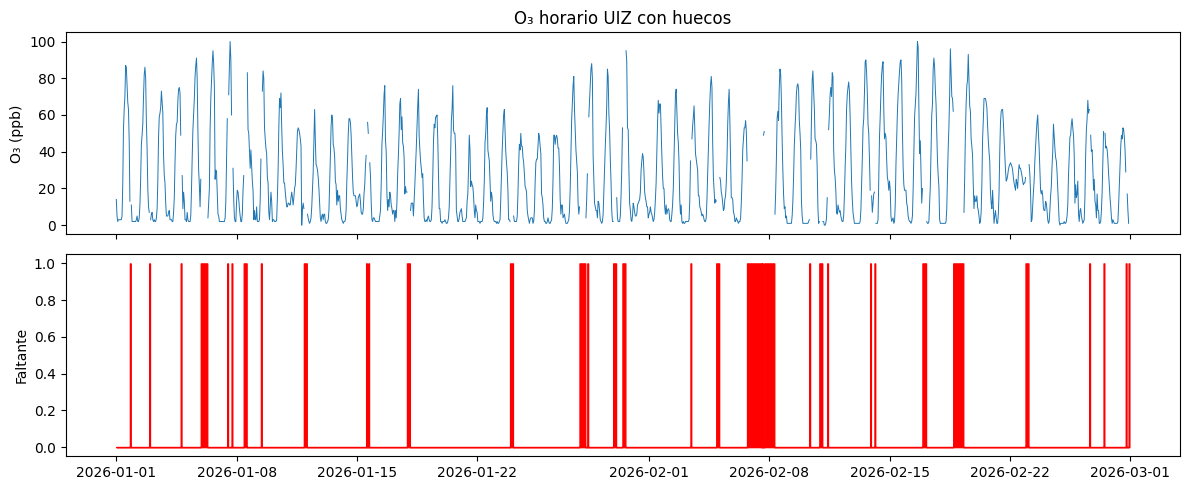

In [5]:
faltante = o3.isna()
n_huecos = int(faltante.sum())
print(f"Horas faltantes: {n_huecos} de {len(o3)} ({100*n_huecos/len(o3):.1f}%)")

# Longitud de cada racha consecutiva de faltantes
grupo = (faltante != faltante.shift()).cumsum()
rachas = faltante.groupby(grupo).agg(["first", "size"])
rachas = rachas[rachas["first"]]["size"]
print(f"Número de rachas (huecos contiguos): {len(rachas)}")
print(f"Longitud mediana: {rachas.median():.0f} h | máxima: {rachas.max()} h")
print("\nDistribución de longitudes de racha:")
print(rachas.value_counts().sort_index().rename("n_rachas"))

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax[0].plot(o3.index, o3.values, lw=0.7)
ax[0].set_ylabel("O₃ (ppb)")
ax[0].set_title("O₃ horario UIZ con huecos")
ax[1].fill_between(o3.index, faltante.astype(int), step="pre", color="red")
ax[1].set_ylabel("Faltante")
plt.tight_layout(); plt.show()

**Decisión de tratamiento.** Como ADF, KPSS y la ACF necesitan una serie regular sin vacíos:
- **Huecos cortos (≤ 3 h):** interpolación lineal en el tiempo. En 3 h el O₃ cambia de forma casi monótona, así que es una aproximación razonable.
- **Huecos largos (> 3 h):** la interpolación lineal borraría el ciclo diario (aplanaría el máximo de la tarde), así que se rellenan con el **promedio de esa hora del día** calculado sobre los datos observados.
- Si queda algún NaN en los extremos de la serie, se rellena con ese mismo perfil horario.

Nada se descarta, para conservar la periodicidad de 24 h que se usa en d), e) y f).

In [6]:
MAX_CORTO = 3

# 1) interpolación lineal solo en huecos <= MAX_CORTO
interp = o3.interpolate(method="time", limit=MAX_CORTO, limit_area="inside")
# interpolate(limit=) rellena el inicio de rachas largas; revertimos esos puntos
longitud_racha = faltante.groupby(grupo).transform("size")
interp[faltante & (longitud_racha > MAX_CORTO)] = np.nan

# 2) huecos largos (y extremos): promedio de la hora del día
perfil_hora = o3.groupby(o3.index.hour).mean()
rellenar = interp.isna()
interp[rellenar] = interp.index[rellenar].hour.map(perfil_hora).values

serie = interp.rename("O3")
print("Faltantes restantes:", int(serie.isna().sum()))
print(f"Imputados por interpolación: {int((faltante & ~rellenar).sum())} | por perfil horario: {int(rellenar.sum())}")

Faltantes restantes: 0
Imputados por interpolación: 18 | por perfil horario: 107


## b) Graficar la serie y su ACF hasta 72 h

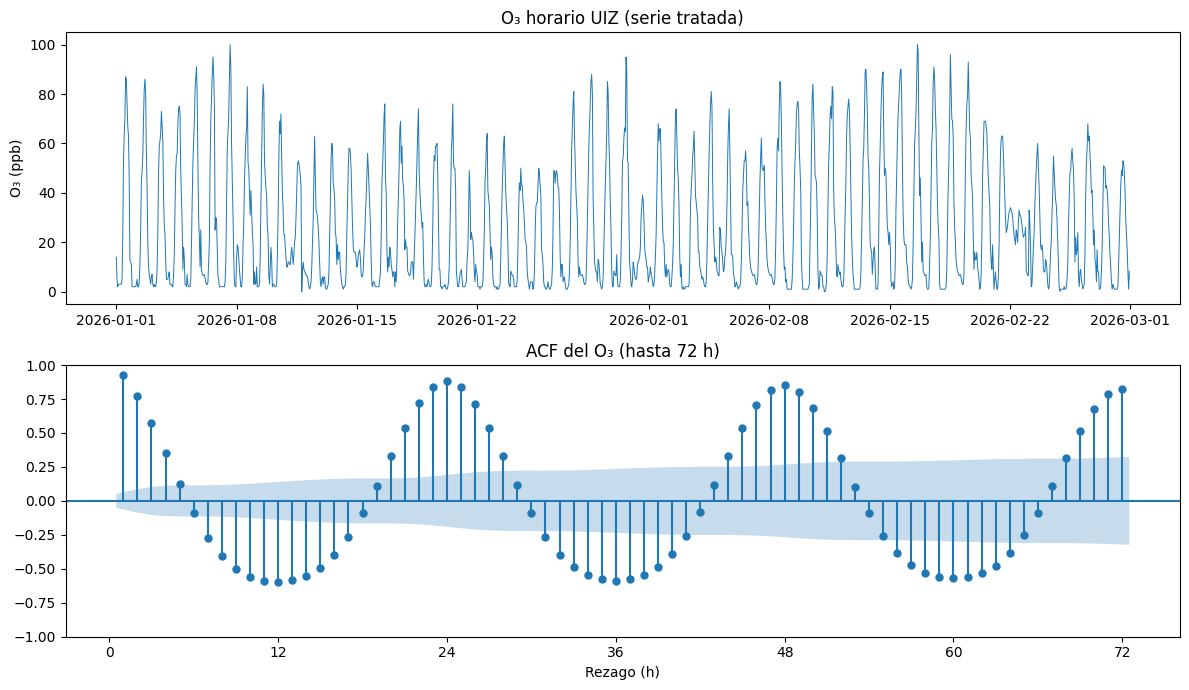

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
ax[0].plot(serie.index, serie.values, lw=0.7)
ax[0].set_title("O₃ horario UIZ (serie tratada)")
ax[0].set_ylabel("O₃ (ppb)")
plot_acf(serie, lags=NLAGS, ax=ax[1], zero=False)
ax[1].set_title("ACF del O₃ (hasta 72 h)")
ax[1].set_xlabel("Rezago (h)")
ax[1].set_xticks(range(0, NLAGS + 1, 12))
plt.tight_layout(); plt.show()

## c) Correr ADF y KPSS
- **ADF:** H₀ = hay raíz unitaria (no estacionaria). p < 0.05 → se rechaza H₀ → evidencia de estacionariedad.
- **KPSS:** H₀ = la serie es estacionaria (alrededor de una constante). p < 0.05 → se rechaza H₀ → evidencia de NO estacionariedad.

Las dos pruebas tienen hipótesis nulas opuestas, así que se leen juntas.

In [8]:
def pruebas(x, nombre):
    x = pd.Series(x).dropna()
    adf_stat, adf_p, adf_lags, _, adf_crit, _ = adfuller(x, autolag="AIC")
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(x, regression="c", nlags="auto")
    adf_ok = adf_p < 0.05
    kpss_ok = kpss_p >= 0.05
    if adf_ok and kpss_ok:
        veredicto = "Estacionaria (ambas pruebas coinciden)"
    elif not adf_ok and not kpss_ok:
        veredicto = "No estacionaria (ambas pruebas coinciden)"
    elif adf_ok and not kpss_ok:
        veredicto = "Contradicción: ADF dice estacionaria, KPSS dice no (posible estacionaria en tendencia/estructura)"
    else:
        veredicto = "Contradicción: ADF no rechaza raíz unitaria, KPSS no rechaza estacionariedad (poca potencia)"
    res = pd.DataFrame({
        "estadístico": [adf_stat, kpss_stat],
        "p-value": [adf_p, kpss_p],
        "rezagos usados": [adf_lags, kpss_lags],
        "H0": ["raíz unitaria", "estacionaria"],
        "rechaza H0 (5%)": [adf_p < 0.05, kpss_p < 0.05],
    }, index=["ADF", "KPSS"])
    print(f"=== {nombre} (n = {len(x)}) ===")
    print(res.round(4).to_string())
    print("→", veredicto, "\n")
    return {"serie": nombre, "n": len(x), "ADF p": adf_p, "KPSS p": kpss_p, "varianza": x.var(), "veredicto": veredicto}

resultados = []
resultados.append(pruebas(serie, "c) Serie original"))

=== c) Serie original (n = 1416) ===
      estadístico  p-value  rezagos usados             H0  rechaza H0 (5%)
ADF       -3.3643   0.0122              22  raíz unitaria             True
KPSS       0.4781   0.0466              19   estacionaria             True
→ Contradicción: ADF dice estacionaria, KPSS dice no (posible estacionaria en tendencia/estructura) 



## d) Restar la media de cada hora del día y repetir c)

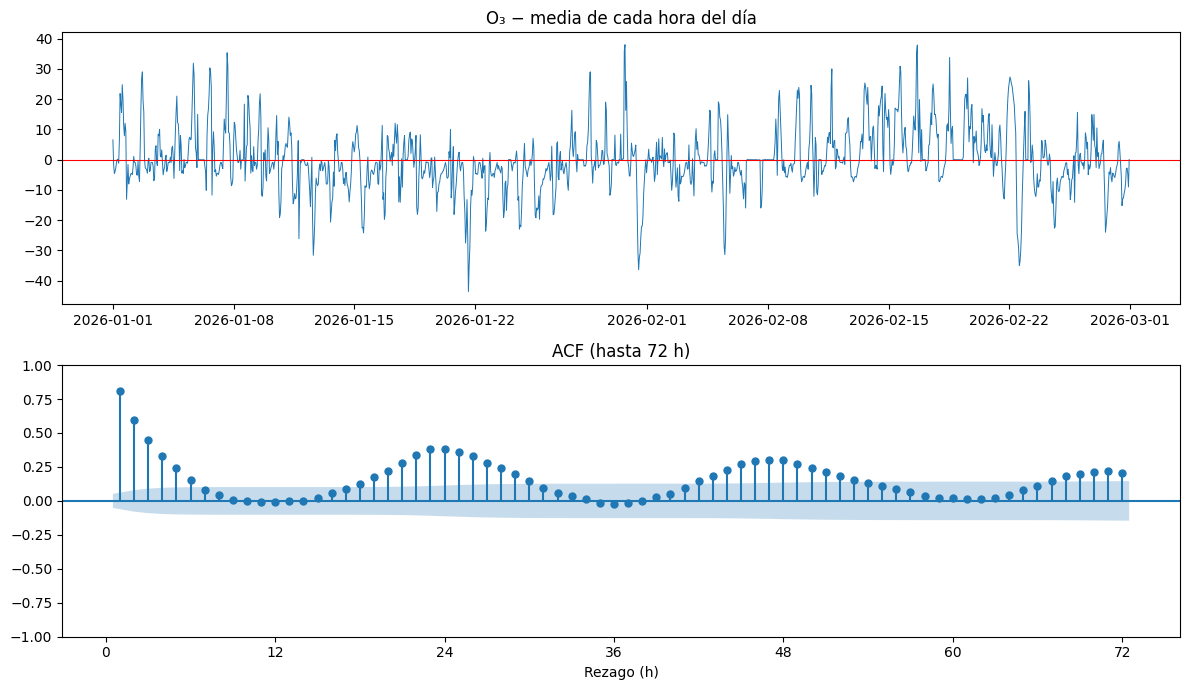

=== d) Sin media por hora (n = 1416) ===
      estadístico  p-value  rezagos usados             H0  rechaza H0 (5%)
ADF       -3.9331   0.0018              22  raíz unitaria             True
KPSS       0.7025   0.0133              20   estacionaria             True
→ Contradicción: ADF dice estacionaria, KPSS dice no (posible estacionaria en tendencia/estructura) 



In [9]:
serie_d = serie - serie.groupby(serie.index.hour).transform("mean")
serie_d.name = "O3 sin media horaria"

fig, ax = plt.subplots(2, 1, figsize=(12, 7))
ax[0].plot(serie_d.index, serie_d.values, lw=0.7)
ax[0].axhline(0, color="red", lw=0.8)
ax[0].set_title("O₃ − media de cada hora del día")
plot_acf(serie_d, lags=NLAGS, ax=ax[1], zero=False)
ax[1].set_title("ACF (hasta 72 h)")
ax[1].set_xlabel("Rezago (h)"); ax[1].set_xticks(range(0, NLAGS + 1, 12))
plt.tight_layout(); plt.show()

resultados.append(pruebas(serie_d, "d) Sin media por hora"))

## e) Restar la media de cada mes × hora y repetir c)

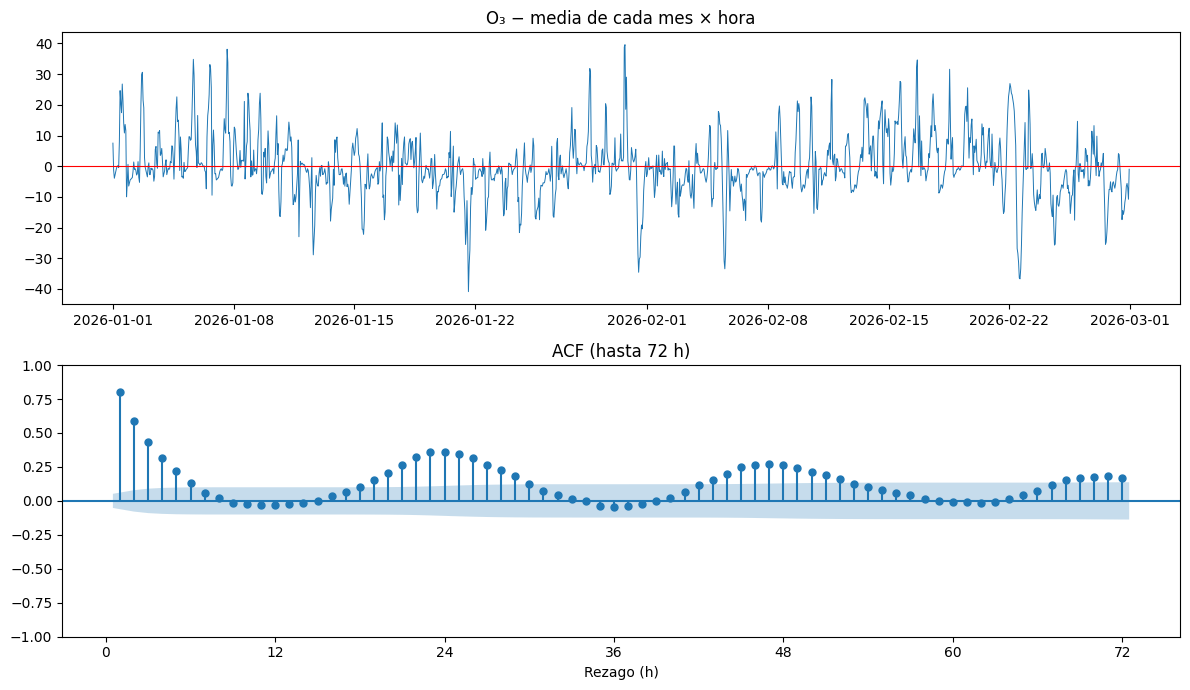

=== e) Sin media mes × hora (n = 1416) ===
      estadístico  p-value  rezagos usados             H0  rechaza H0 (5%)
ADF       -4.1336   0.0009              22  raíz unitaria             True
KPSS       0.3725   0.0890              20   estacionaria            False
→ Estacionaria (ambas pruebas coinciden) 



In [10]:
serie_e = serie - serie.groupby([serie.index.month, serie.index.hour]).transform("mean")
serie_e.name = "O3 sin media mes x hora"

fig, ax = plt.subplots(2, 1, figsize=(12, 7))
ax[0].plot(serie_e.index, serie_e.values, lw=0.7)
ax[0].axhline(0, color="red", lw=0.8)
ax[0].set_title("O₃ − media de cada mes × hora")
plot_acf(serie_e, lags=NLAGS, ax=ax[1], zero=False)
ax[1].set_title("ACF (hasta 72 h)")
ax[1].set_xlabel("Rezago (h)"); ax[1].set_xticks(range(0, NLAGS + 1, 12))
plt.tight_layout(); plt.show()

resultados.append(pruebas(serie_e, "e) Sin media mes × hora"))

## f) Diferencia de 24 h, repetir c) y comparar su ACF y varianza con e)

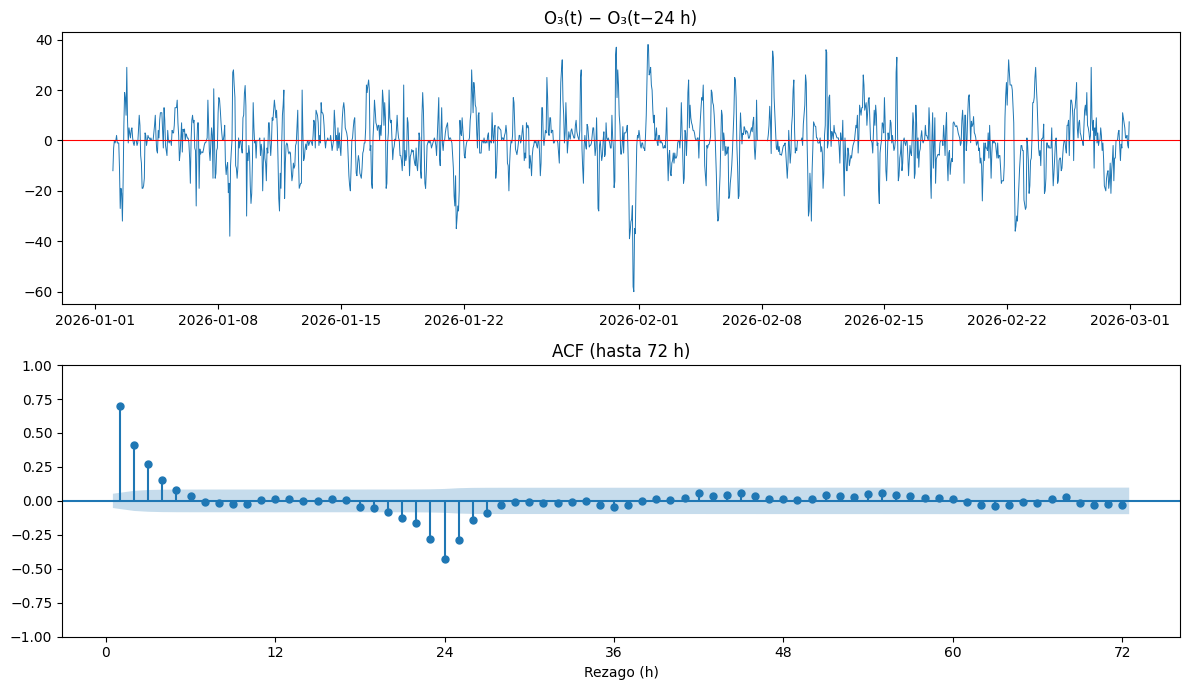

=== f) Diferencia 24 h (n = 1392) ===
      estadístico  p-value  rezagos usados             H0  rechaza H0 (5%)
ADF       -8.7407      0.0              24  raíz unitaria             True
KPSS       0.0330      0.1              16   estacionaria            False
→ Estacionaria (ambas pruebas coinciden) 



In [11]:
serie_f = serie.diff(24).dropna()
serie_f.name = "O3 diferencia 24 h"

fig, ax = plt.subplots(2, 1, figsize=(12, 7))
ax[0].plot(serie_f.index, serie_f.values, lw=0.7)
ax[0].axhline(0, color="red", lw=0.8)
ax[0].set_title("O₃(t) − O₃(t−24 h)")
plot_acf(serie_f, lags=NLAGS, ax=ax[1], zero=False)
ax[1].set_title("ACF (hasta 72 h)")
ax[1].set_xlabel("Rezago (h)"); ax[1].set_xticks(range(0, NLAGS + 1, 12))
plt.tight_layout(); plt.show()

resultados.append(pruebas(serie_f, "f) Diferencia 24 h"))

### Comparación f) vs. e): ACF y varianza

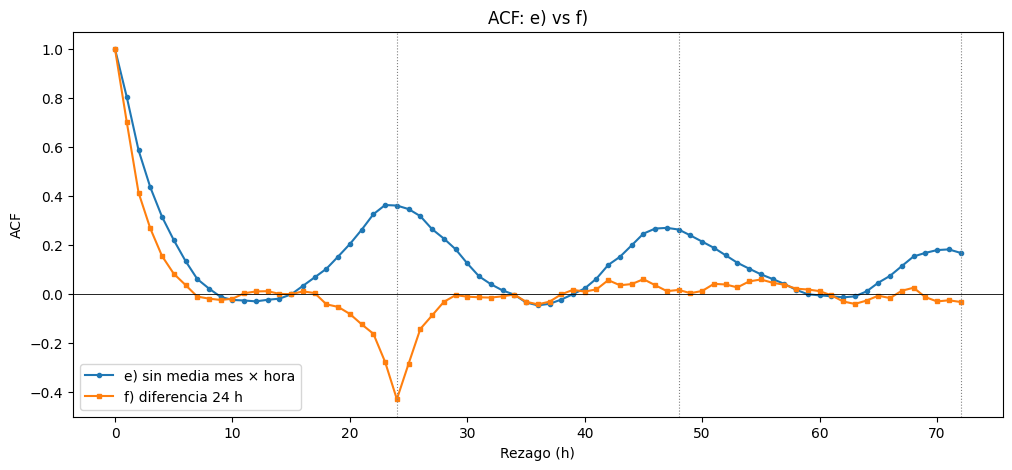

        ACF e)  ACF f)
lag 1    0.804   0.702
lag 2    0.588   0.414
lag 12  -0.030   0.010
lag 24   0.361  -0.430
lag 48   0.263   0.017
lag 72   0.168  -0.033

Varianza original      :    606.5
Varianza e) mes×hora   :     98.1  (16% de la original)
Varianza f) dif. 24 h  :    125.2  (21% de la original)
Razón var(f)/var(e)    : 1.28


,n,ADF p,KPSS p,varianza,veredicto
serie,,,,,
c) Serie original,1416,0.0122,0.0466,606.4692,"Contradicción: ADF dice estacionaria, KPSS dic..."
d) Sin media por hora,1416,0.0018,0.0133,101.7477,"Contradicción: ADF dice estacionaria, KPSS dic..."
e) Sin media mes × hora,1416,0.0009,0.0890,98.1419,Estacionaria (ambas pruebas coinciden)
f) Diferencia 24 h,1392,0.0000,0.1000,125.2427,Estacionaria (ambas pruebas coinciden)


In [12]:
# ACF superpuestas
acf_e = acf(serie_e, nlags=NLAGS, fft=True)
acf_f = acf(serie_f, nlags=NLAGS, fft=True)

plt.figure(figsize=(12, 5))
plt.plot(range(NLAGS + 1), acf_e, label="e) sin media mes × hora", marker="o", ms=3)
plt.plot(range(NLAGS + 1), acf_f, label="f) diferencia 24 h", marker="s", ms=3)
plt.axhline(0, color="k", lw=0.6)
for k in (24, 48, 72):
    plt.axvline(k, color="gray", ls=":", lw=0.8)
plt.xlabel("Rezago (h)"); plt.ylabel("ACF"); plt.legend()
plt.title("ACF: e) vs f)")
plt.show()

comp = pd.DataFrame({
    "ACF e)": [acf_e[k] for k in (1, 2, 12, 24, 48, 72)],
    "ACF f)": [acf_f[k] for k in (1, 2, 12, 24, 48, 72)],
}, index=[f"lag {k}" for k in (1, 2, 12, 24, 48, 72)])
print(comp.round(3))

var_orig, var_e, var_f = serie.var(), serie_e.var(), serie_f.var()
print(f"\nVarianza original      : {var_orig:8.1f}")
print(f"Varianza e) mes×hora   : {var_e:8.1f}  ({100*var_e/var_orig:.0f}% de la original)")
print(f"Varianza f) dif. 24 h  : {var_f:8.1f}  ({100*var_f/var_orig:.0f}% de la original)")
print(f"Razón var(f)/var(e)    : {var_f/var_e:.2f}")

pd.DataFrame(resultados).set_index("serie").round(4)